## Exploratory Data Analysis on a Dataset

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


#### 1.Data Cleaning and Preparation:


##### Load Dataset

In [157]:
df = pd.read_csv("Cardiotocographic.csv")

df.head()


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [158]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

In [159]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [160]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


#### Handlie missing values - imputation

In [161]:
df_clean = df.copy()

for col in df_clean.columns:
    if df_clean[col].dtype in ['float64', 'int64']:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())


In [162]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [163]:
df_clean.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

#### Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).


In [164]:
df_clean.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

All columns in the dataset are stored as numerical (float64) values. There are no inconsistencies in data types, and no columns need conversion.

#### Detect and treat outliers if necessary.

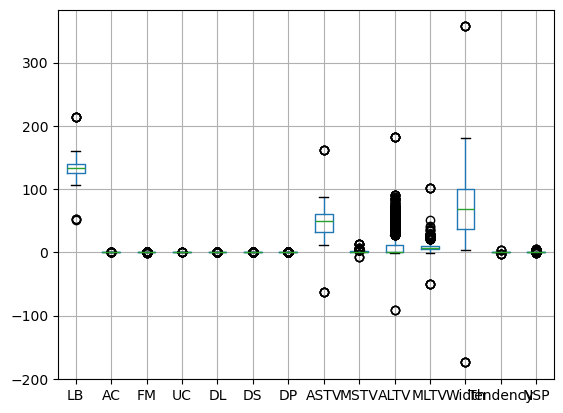

In [165]:
df_clean.boxplot()
plt.show()

In [166]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Treat (cap) outliers
    df[col] = df_clean[col].clip(lower, upper)

print("Outliers detected and treated successfully.")

Outliers detected and treated successfully.


<Axes: >

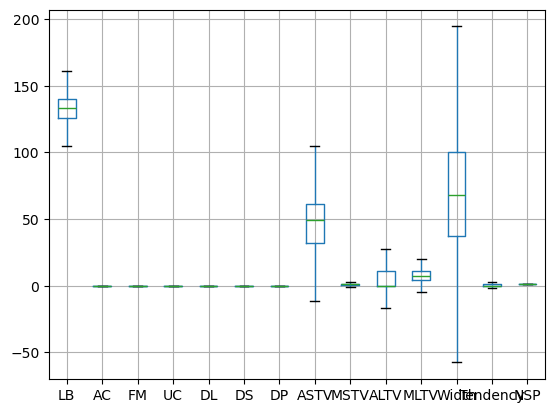

In [167]:
df.boxplot()

#### 2.Statistical Summary:

In [168]:
summary = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Std Dev': df.std(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75),
    'IQR':df.quantile(0.75)-df.quantile(0.25)
})
print(summary)

                Mean      Median    Std Dev          Q1          Q3        IQR
LB        133.293725  133.000000   9.930227  126.000000  140.000000  14.000000
AC          0.003147    0.001668   0.003826    0.000000    0.005606   0.005606
FM          0.001568    0.000000   0.002485    0.000000    0.002567   0.002567
UC          0.004362    0.004484   0.003001    0.001851    0.006536   0.004685
DL          0.001770    0.000000   0.002668    0.000000    0.003289   0.003289
DS          0.000000    0.000000   0.000000    0.000000    0.000000   0.000000
DP          0.000000    0.000000   0.000000    0.000000    0.000000   0.000000
ASTV       46.981873   49.000000  17.612745   32.000000   61.000000  29.000000
MSTV        1.304644    1.200000   0.781091    0.700000    1.700000   1.000000
ALTV        6.691678    0.000000  10.378400    0.000000   11.000000  11.000000
MLTV        8.016212    7.500000   5.046784    4.600000   10.800000   6.200000
Width      70.321076   68.000000  39.570633   37.000

### 3.Data Visualization:


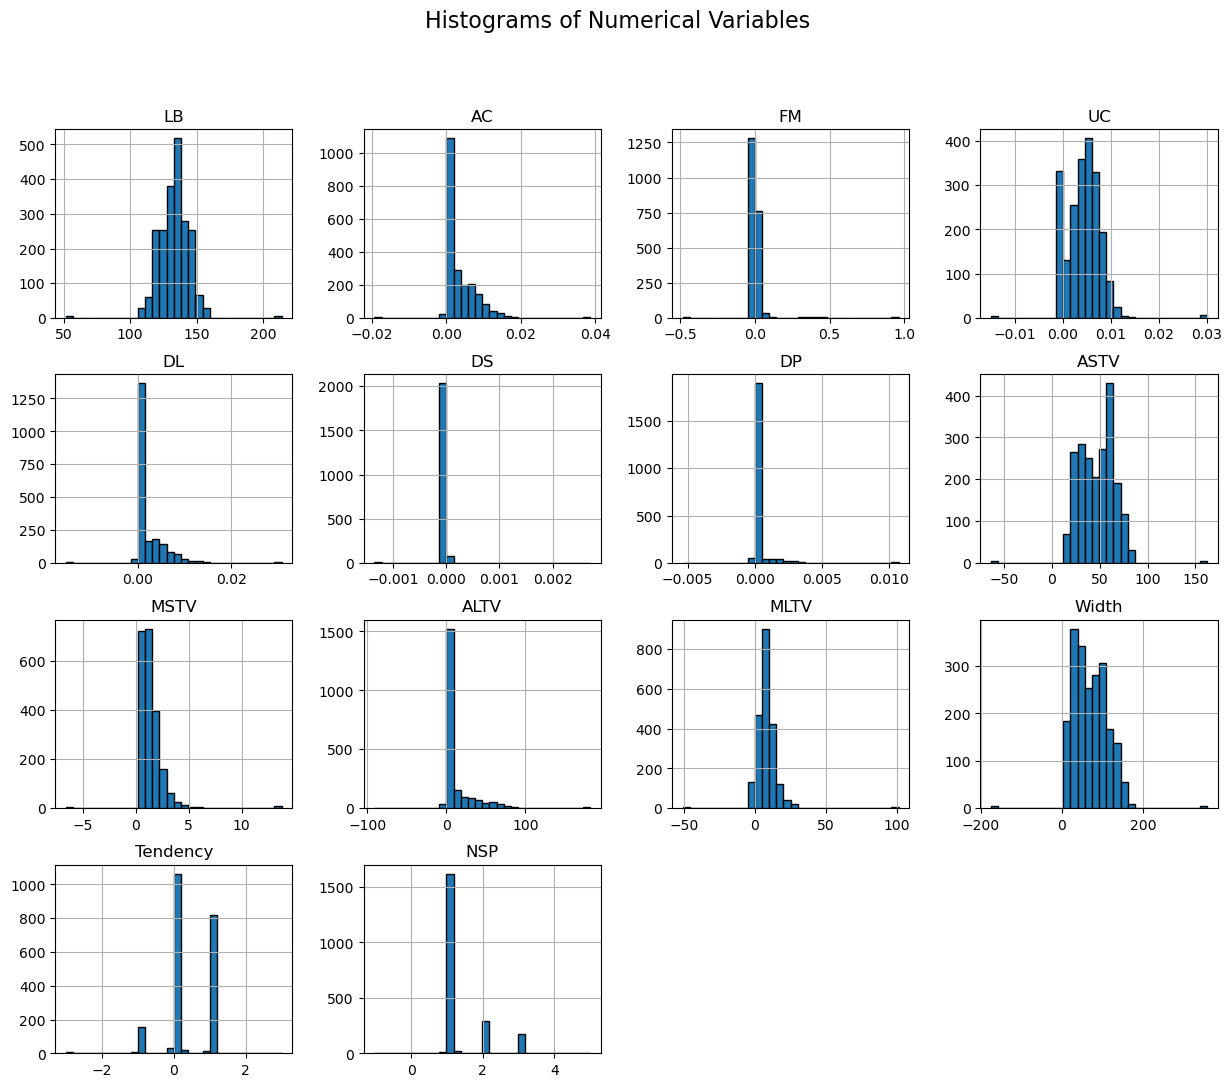

In [169]:
df_clean.hist(bins=30, figsize=(15, 12), edgecolor='black')
plt.suptitle("Histograms of Numerical Variables", fontsize=16)
plt.show()

In [170]:
corr = df_clean.corr()
corr

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
LB,1.000000,-0.062839,0.018776,-0.166201,-0.126536,-0.005438,-0.047724,0.241857,-0.169561,0.210446,-0.003457,-0.118425,0.236864,0.131843
AC,-0.062839,1.000000,0.009432,0.071863,-0.093196,-0.033101,-0.083277,-0.230439,0.133649,-0.271041,-0.104875,0.234735,0.031977,-0.312022
FM,0.018776,0.009432,1.000000,-0.053226,0.009718,0.029899,0.121274,-0.032691,0.017055,-0.011936,-0.006237,0.097204,-0.018338,0.074048
UC,-0.166201,0.071863,-0.053226,1.000000,0.190128,-0.006922,0.070501,-0.181161,0.189406,-0.227304,-0.049351,0.107159,-0.066463,-0.185001
DL,-0.126536,-0.093196,0.009718,0.190128,1.000000,0.058430,0.144940,-0.069361,0.410102,-0.186967,-0.165198,0.408664,-0.023490,0.025342
DS,-0.005438,-0.033101,0.029899,-0.006922,0.058430,1.000000,0.004285,0.008425,0.016077,-0.004392,0.034349,0.040832,-0.015398,0.065400
DP,-0.047724,-0.083277,0.121274,0.070501,0.144940,0.004285,1.000000,0.038117,0.119250,-0.077654,-0.114084,0.175340,-0.130395,0.294472
ASTV,0.241857,-0.230439,-0.032691,-0.181161,-0.069361,0.008425,0.038117,1.000000,-0.293882,0.357497,-0.219728,-0.206942,-0.010892,0.421313
MSTV,-0.169561,0.133649,0.017055,0.189406,0.410102,0.016077,0.119250,-0.293882,1.000000,-0.291935,0.028779,0.433064,-0.036660,-0.094630
ALTV,0.210446,-0.271041,-0.011936,-0.227304,-0.186967,-0.004392,-0.077654,0.357497,-0.291935,1.000000,-0.107568,-0.345997,0.036722,0.365357


In [171]:
cols = ['LB','AC','FM','UC','DL','DS','DP','ASTV','MSTV','ALTV','MLTV','Width','Tendency','NSP']
print(df_clean.nunique()) 

LB           154
AC          1068
FM           776
UC          1364
DL           822
DS           115
DP           265
ASTV         183
MSTV         165
ALTV         195
MLTV         352
Width        262
Tendency     112
NSP          112
dtype: int64


In [172]:
df = df_clean.drop(columns=[col for col in cols if df[col].nunique() <= 1])

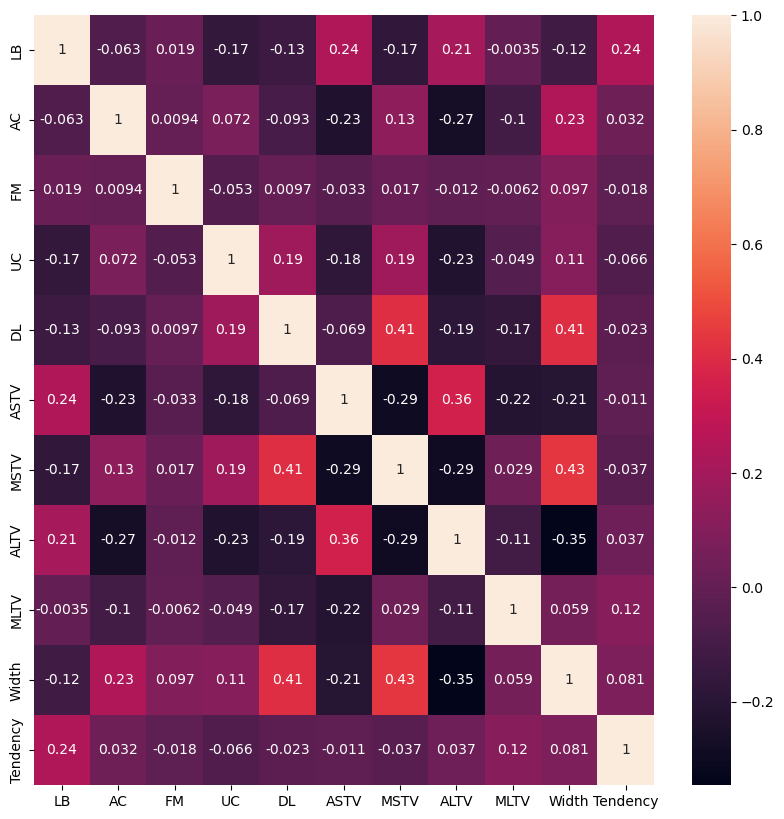

In [173]:
plt.figure(figsize=(10,10))
corr = df.corr()
ax=sns.heatmap(corr, annot=True)

plt.show()


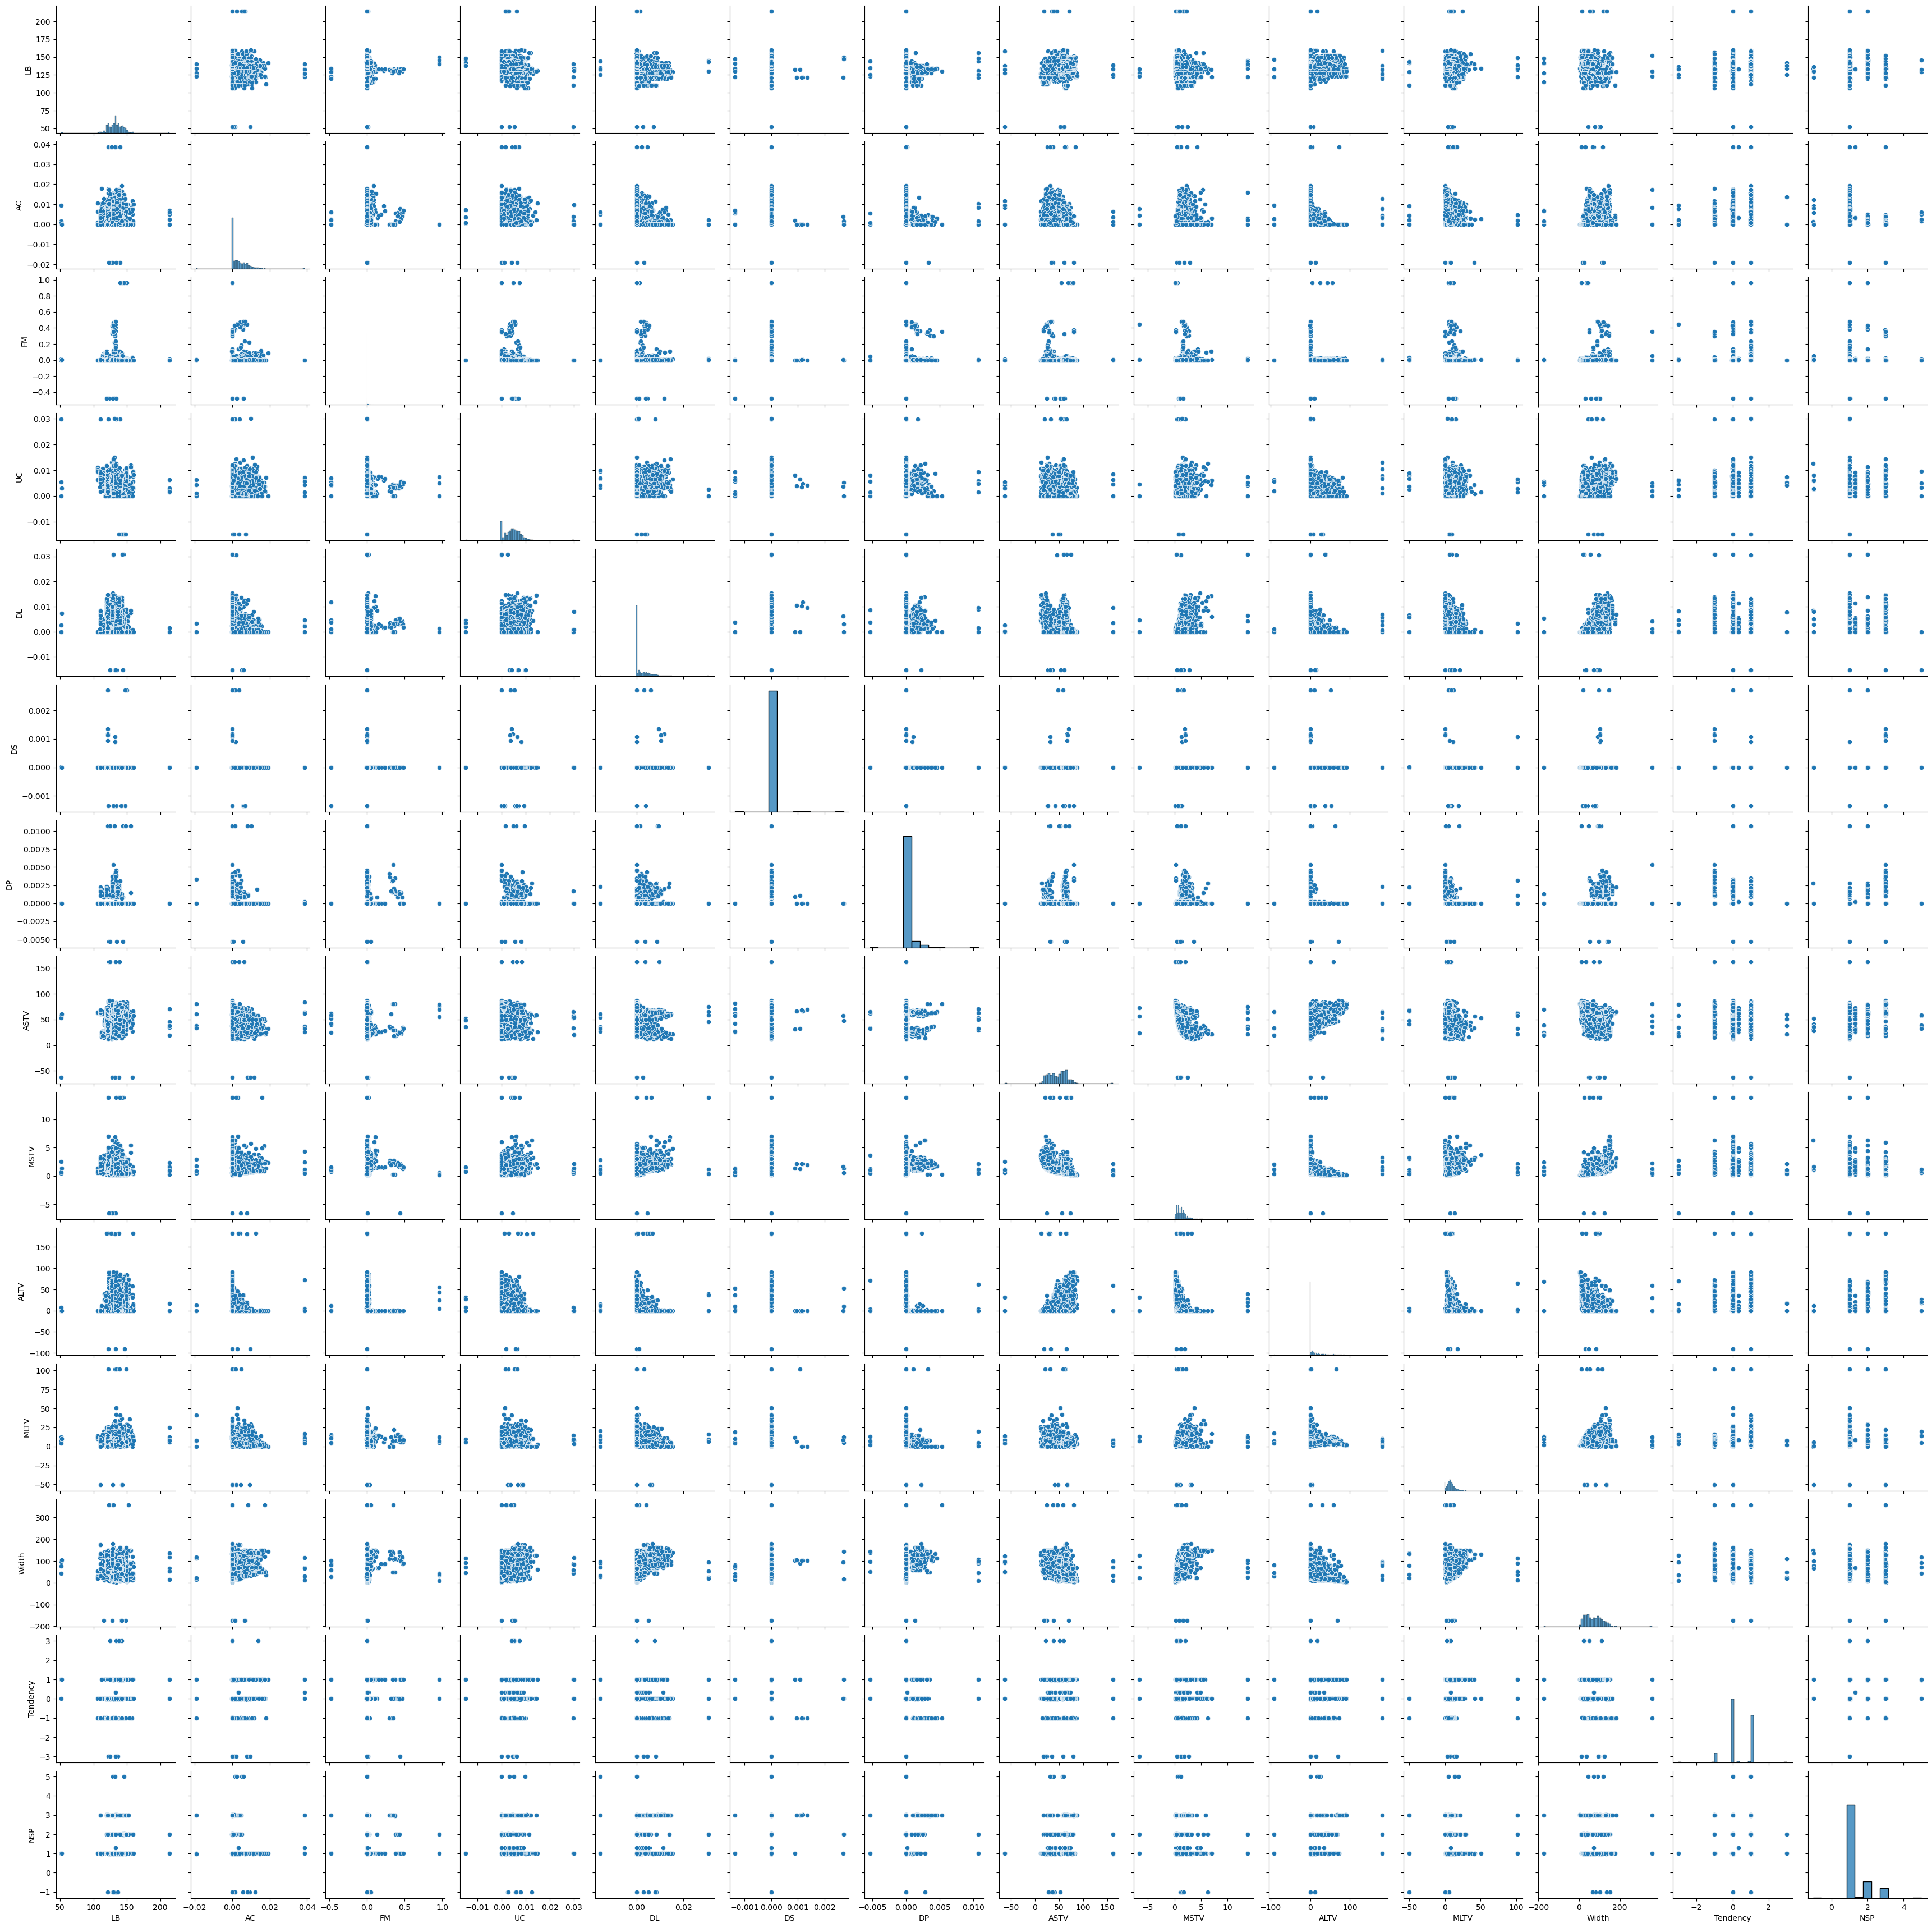

In [175]:
sns.pairplot(df_clean)
plt.show()

### 4. Pattern Recognition and Insights:

In [176]:
# as the above heatmap and correlation matrix it is visible that MSTV & Width , ASTV & ALTV,DL & MSTV have a strong positive correlations  
# and ALTV & MSTV,ASTV & MSTV have a very strong negative correlation
# this implies that MSTV can be a help to predict width or DL

In [177]:
# there is no any kind of temporal data

### 5. Conclusion

In [178]:
#EDA shows a mixture of strong, weak, and negative correlations. Key patterns like the relationship between variability measures (MSTV, ALTV, ASTV) and other variables (e.g., Width, DL) can guide feature selection, monitoring, and predictive modeling.